In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Cấu hình lưu ảnh tự động và định dạng biểu đồ
os.makedirs("hinh_anh", exist_ok=True)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
print("Đã tải thư viện và cấu hình hệ thống thành công!")

Đã tải thư viện và cấu hình hệ thống thành công!


In [ ]:
URL = "https://raw.githubusercontent.com/gakudo-ai/open-datasets/refs/heads/main/Mall_Customers.csv"
try:
    df = pd.read_csv(URL)
    print("Đã tải dữ liệu trực tiếp từ Internet thành công.")
except Exception:
    df = pd.read_csv("Mall_Customers.csv")
    print("Đọc dữ liệu từ file dự phòng local thành công.")

print("\nHển thị 5 dòng dữ liệu đầu tiên:")
df.head()

Đã tải dữ liệu trực tiếp từ Internet thành công.

Hển thị 5 dòng dữ liệu đầu tiên:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# 1. Loại bỏ dữ liệu trùng lặp (nếu có)
df = df.drop_duplicates().reset_index(drop=True)

# 2. Đổi tên cột sang tiếng Việt cho trực quan
df = df.rename(columns={
    "Annual Income (k$)": "ThuNhap",
    "Spending Score (1-100)": "DiemChiTieu",
    "Age": "Tuoi",
    "Gender": "GioiTinh"
})

# 3. Việt hóa dữ liệu cột Giới tính (Chuyển Male -> Nam, Female -> Nữ)
df["GioiTinh"] = df["GioiTinh"].map({"Male": "Nam", "Female": "Nữ"})

print("Thông tin cấu trúc các trường thuộc tính:")
df.info()
print("\nBảng thống kê mô tả số liệu tổng quan:")
df.describe()

Thông tin cấu trúc các trường thuộc tính:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   CustomerID   200 non-null    int64 
 1   GioiTinh     200 non-null    object
 2   Tuoi         200 non-null    int64 
 3   ThuNhap      200 non-null    int64 
 4   DiemChiTieu  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Bảng thống kê mô tả số liệu tổng quan:


,CustomerID,Tuoi,ThuNhap,DiemChiTieu
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Tỉ lệ giới tính trong tập dữ liệu:
GioiTinh
Nữ     112
Nam     88
Name: count, dtype: int64

Tuổi trung bình của tập khách hàng: 38.8


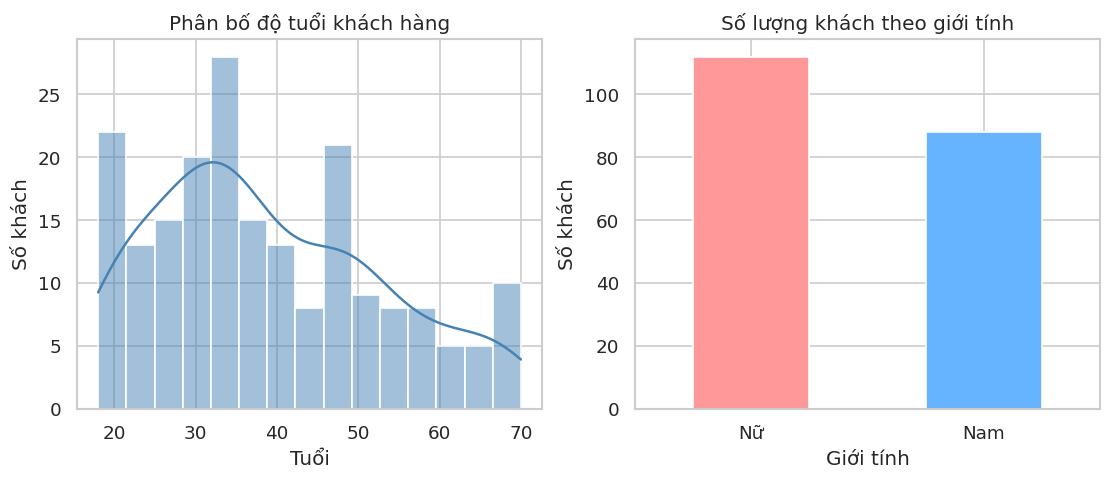

In [ ]:
print("Tỉ lệ giới tính trong tập dữ liệu:")
print(df["GioiTinh"].value_counts())
print("\nTuổi trung bình của tập khách hàng:", round(df["Tuoi"].mean(), 1))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["Tuoi"], bins=15, kde=True, ax=ax[0], color="steelblue")
ax[0].set_title("Phân bố độ tuổi khách hàng")
ax[0].set_xlabel("Tuổi"); ax[0].set_ylabel("Số khách")

df["GioiTinh"].value_counts().plot(kind="bar", ax=ax[1], color=["#ff9999", "#66b3ff"])
ax[1].set_title("Số lượng khách theo giới tính")
ax[1].set_xlabel("Giới tính"); ax[1].set_ylabel("Số khách")
plt.xticks(rotation=0)
plt.savefig("hinh_anh/cau1_tuoi_gioitinh.png", bbox_inches="tight")
plt.show()

Thống kê chi tiết về mức thu nhập hằng năm (nghìn $):
count    200.000000
mean      60.560000
std       26.264721
min       15.000000
25%       41.500000
50%       61.500000
75%       78.000000
max      137.000000
Name: ThuNhap, dtype: float64


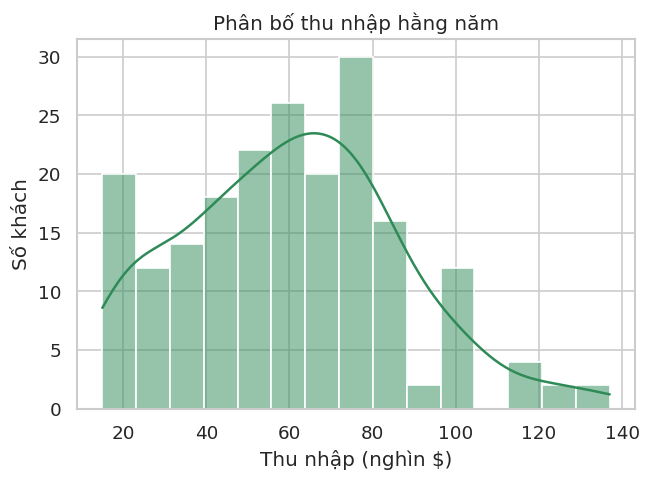

In [ ]:
print("Thống kê chi tiết về mức thu nhập hằng năm (nghìn $):")
print(df["ThuNhap"].describe())

plt.figure(figsize=(6, 4))
sns.histplot(df["ThuNhap"], bins=15, kde=True, color="seagreen")
plt.title("Phân bố thu nhập hằng năm")
plt.xlabel("Thu nhập (nghìn $)"); plt.ylabel("Số khách")
plt.savefig("hinh_anh/cau2_thu_nhap.png", bbox_inches="tight")
plt.show()

Điểm chi tiêu trung bình theo giới tính:
GioiTinh
Nam    48.511364
Nữ     51.526786
Name: DiemChiTieu, dtype: float64


/tmp/ipykernel_967/4149657488.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="GioiTinh", y="DiemChiTieu", palette="Set2")


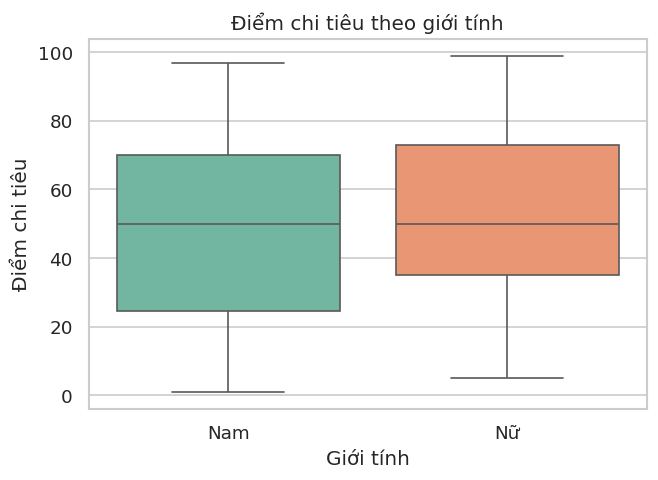

In [ ]:
print("Điểm chi tiêu trung bình theo giới tính:")
print(df.groupby("GioiTinh")["DiemChiTieu"].mean())

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="GioiTinh", y="DiemChiTieu", palette="Set2")
plt.title("Điểm chi tiêu theo giới tính")
plt.xlabel("Giới tính"); plt.ylabel("Điểm chi tiêu")
plt.savefig("hinh_anh/cau3_chitieu_gioitinh.png", bbox_inches="tight")
plt.show()

Hệ số tương quan giữa Tuổi và Điểm chi tiêu: -0.327


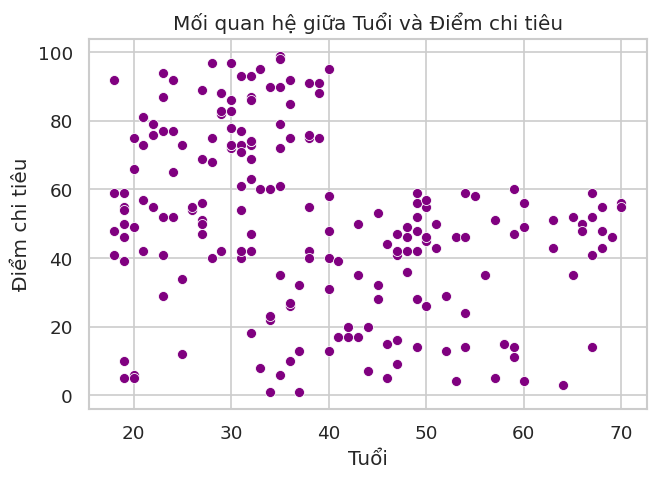

In [ ]:
he_so_4 = df["Tuoi"].corr(df["DiemChiTieu"])
print(f"Hệ số tương quan giữa Tuổi và Điểm chi tiêu: {he_so_4:.3f}")

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="Tuoi", y="DiemChiTieu", color="purple")
plt.title("Mối quan hệ giữa Tuổi và Điểm chi tiêu")
plt.xlabel("Tuổi"); plt.ylabel("Điểm chi tiêu")
plt.savefig("hinh_anh/cau4_tuoi_chitieu.png", bbox_inches="tight")
plt.show()

Hệ số tương quan giữa Thu nhập và Điểm chi tiêu: 0.010


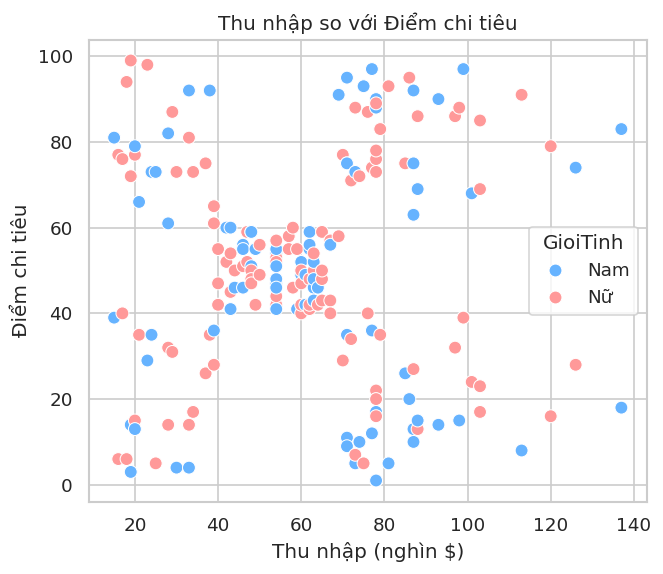

In [ ]:
he_so_5 = df["ThuNhap"].corr(df["DiemChiTieu"])
print(f"Hệ số tương quan giữa Thu nhập và Điểm chi tiêu: {he_so_5:.3f}")

plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x="ThuNhap", y="DiemChiTieu", hue="GioiTinh", s=60, palette={"Nam": "#66b3ff", "Nữ": "#ff9999"})
plt.title("Thu nhập so với Điểm chi tiêu")
plt.xlabel("Thu nhập (nghìn $)"); plt.ylabel("Điểm chi tiêu")
plt.savefig("hinh_anh/cau5_thunhap_chitieu.png", bbox_inches="tight")
plt.show()

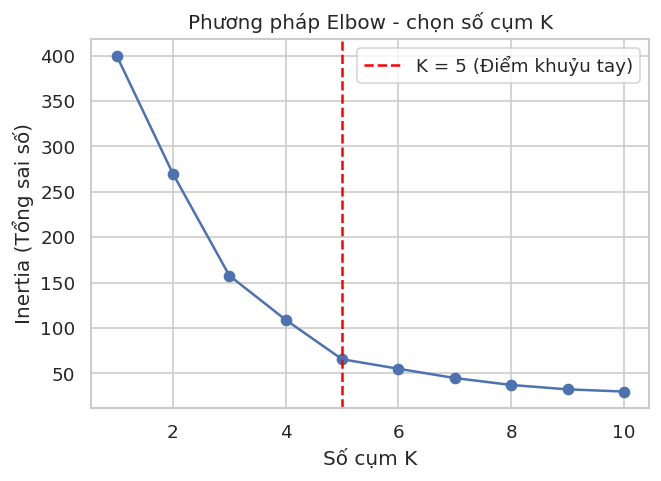

In [ ]:
X = df[["ThuNhap", "DiemChiTieu"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Chạy thử nghiệm K từ 1 đến 10 để tính toán độ phân tán Inertia
inertia = []
for k in range(1, 11):
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_tmp.fit(X_scaled)
    inertia.append(km_tmp.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), inertia, marker="o")
plt.title("Phương pháp Elbow - chọn số cụm K")
plt.xlabel("Số cụm K"); plt.ylabel("Inertia (Tổng sai số)")
plt.axvline(x=5, color="red", linestyle="--", label="K = 5 (Điểm khuỷu tay)")
plt.legend()
plt.savefig("hinh_anh/ml1_elbow.png", bbox_inches="tight")
plt.show()

Thông số trung bình đặc trưng của 5 nhóm khách hàng:
      Tuoi  ThuNhap  DiemChiTieu  SoKhach
Nhom                                     
0     42.7     55.3         49.5       81
1     32.7     86.5         82.1       39
2     25.3     25.7         79.4       22
3     41.1     88.2         17.1       35
4     45.2     26.3         20.9       23


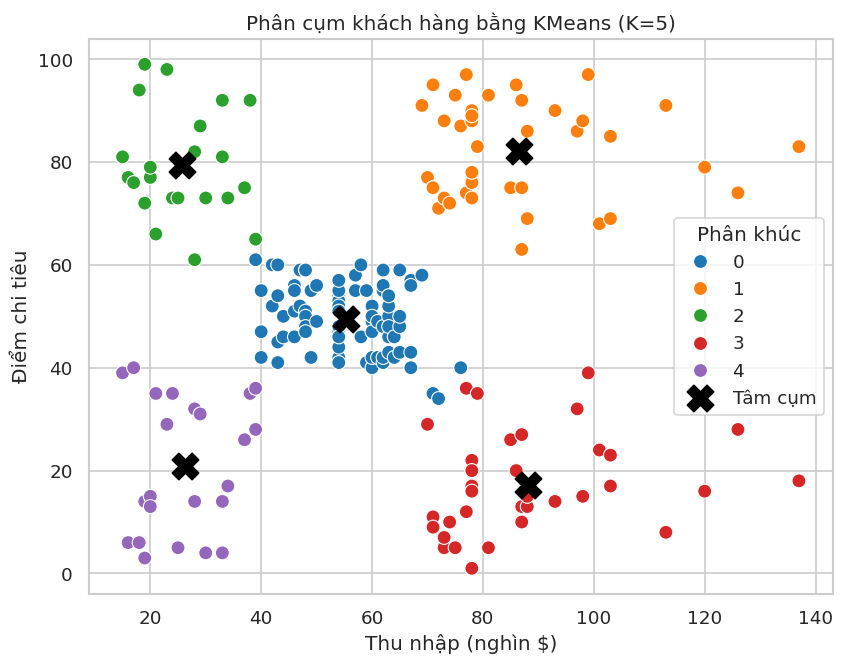

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["Nhom"] = kmeans.fit_predict(X_scaled)

# Xuất kết quả phân tích đặc trưng của từng nhóm
dac_diem = df.groupby("Nhom")[["Tuoi", "ThuNhap", "DiemChiTieu"]].mean().round(1)
dac_diem["SoKhach"] = df["Nhom"].value_counts().sort_index()
print("Thông số trung bình đặc trưng của 5 nhóm khách hàng:")
print(dac_diem)

# Vẽ biểu đồ không gian phân cụm
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="ThuNhap", y="DiemChiTieu", hue="Nhom", palette="tab10", s=70)
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], s=250, c="black", marker="X", label="Tâm cụm")
plt.title("Phân cụm khách hàng bằng KMeans (K=5)")
plt.xlabel("Thu nhập (nghìn $)"); plt.ylabel("Điểm chi tiêu")
plt.legend(title="Phân khúc")
plt.savefig("hinh_anh/ml1_phan_cum.png", bbox_inches="tight")
plt.show()

In [ ]:
data = df.copy()
data["GioiTinh_num"] = data["GioiTinh"].map({"Nam": 1, "Nữ": 0})

features = ["Tuoi", "GioiTinh_num", "ThuNhap"]
X_clf = data[features]
y_clf = data["Nhom"]

# Phân chia dữ liệu Train/Test theo tỷ lệ 75/25
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.25, random_state=42, stratify=y_clf
)

# Huấn luyện mô hình
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(f"Độ chính xác toàn cục (Accuracy Score): {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nBáo cáo đánh giá chi tiết ma trận phân lớp:")
print(classification_report(y_test, y_pred, zero_division=0))

Độ chính xác toàn cục (Accuracy Score): 86.00%

Báo cáo đánh giá chi tiết ma trận phân lớp:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       0.88      0.70      0.78        10
           2       0.67      0.80      0.73         5
           3       0.80      0.89      0.84         9
           4       0.80      0.67      0.73         6

    accuracy                           0.86        50
   macro avg       0.82      0.81      0.81        50
weighted avg       0.86      0.86      0.86        50



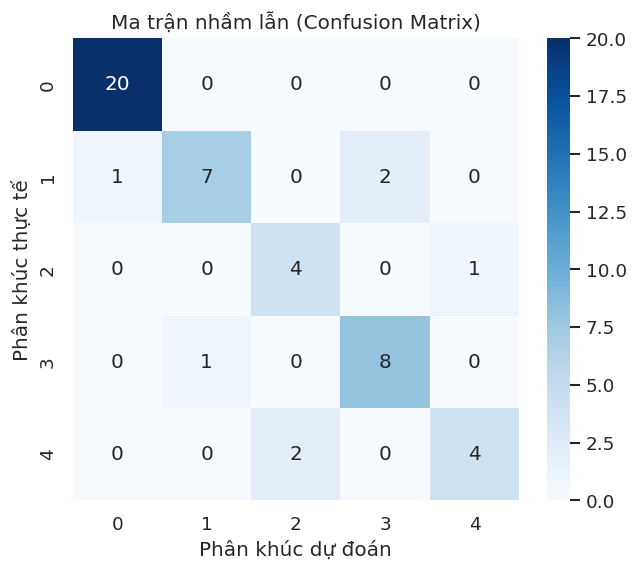

Mức độ ảnh hưởng của các thuộc tính nhân khẩu học:
Thu nhập     0.701324
Tuổi         0.298676
Giới tính    0.000000
dtype: float64


In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Ma trận nhầm lẫn (Confusion Matrix)")
plt.ylabel("Phân khúc thực tế"); plt.xlabel("Phân khúc dự đoán")
plt.savefig("hinh_anh/ml2_ma_tran_nham_lan.png", bbox_inches="tight")
plt.show()

# Trực quan hóa độ quan trọng của các biến đầu vào
do_quan_trong = pd.Series(clf.feature_importances_, index=["Tuổi", "Giới tính", "Thu nhập"]).sort_values(ascending=False)
print("Mức độ ảnh hưởng của các thuộc tính nhân khẩu học:")
print(do_quan_trong)

In [ ]:
# Giả định một khách hàng mới bước vào trung tâm: 30 tuổi, Nam (1), thu nhập hằng năm 70k$
khach_moi = pd.DataFrame([[30, 1, 70]], columns=features)
du_doan_nhom = clf.predict(khach_moi)[0]

print(f"--- THỬ NGHIỆM ĐIỀU HƯỚNG MARKETING TỰ ĐỘNG ---")
print(f"Kết quả dự đoán phân khúc cho khách hàng mới: Nhóm {du_doan_nhom}")

--- THỬ NGHIỆM ĐIỀU HƯỚNG MARKETING TỰ ĐỘNG ---
Kết quả dự đoán phân khúc cho khách hàng mới: Nhóm 1
